In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Upload your shipments.csv file")
uploaded = files.upload()

Upload your shipments.csv file


Saving shipments.csv to shipments.csv


In [3]:
# ── Load shipments ─────────────────────────────────────────────
df = pd.read_csv('shipments.csv')
df['shipment_date'] = pd.to_datetime(df['shipment_date'])

# ── Aggregate to daily level ───────────────────────────────────
daily = df.groupby('shipment_date').agg(
    total_shipments  = ('shipment_date', 'count'),
    total_units      = ('unit_count', 'sum'),
    late_count       = ('status', lambda x: (x == 'late').sum()),
    cancelled_count  = ('status', lambda x: (x == 'cancelled').sum()),
    late_risk_sum    = ('late_risk_flag', 'sum'),
    avg_units        = ('unit_count', 'mean'),
    unique_carriers  = ('carrier_id', 'nunique'),
    unique_docks     = ('scheduled_dock', 'nunique')
).reset_index()

daily = daily.sort_values('shipment_date').reset_index(drop=True)

# ── Build features ─────────────────────────────────────────────
daily['late_rate']        = (daily['late_count'] / daily['total_shipments'] * 100).round(2)
daily['cancel_rate']      = (daily['cancelled_count'] / daily['total_shipments'] * 100).round(2)
daily['day_of_week']      = daily['shipment_date'].dt.dayofweek
daily['month']            = daily['shipment_date'].dt.month
daily['is_weekend']       = (daily['day_of_week'] >= 5).astype(int)
daily['is_peak_season']   = daily['month'].isin([11, 12, 1]).astype(int)
daily['vol_7day_avg']     = daily['total_shipments'].rolling(7, min_periods=1).mean().round(1)
daily['vol_vs_avg']       = ((daily['total_shipments'] - daily['vol_7day_avg'])
                              / daily['vol_7day_avg'] * 100).round(2)
daily['late_7day_avg']    = daily['late_rate'].rolling(7, min_periods=1).mean().round(2)
daily['volume_spike']     = (daily['vol_vs_avg'] > 15).astype(int)

# ── Create risk target label ───────────────────────────────────
# A day is HIGH RISK if late rate > 65% OR cancelled > 5% of shipments
daily['is_high_risk'] = (
    (daily['late_rate'] > 65) |
    (daily['cancel_rate'] > 5)
).astype(int)

# Use only clean data period
daily = daily[daily['shipment_date'] < '2017-10-01'].copy()

print(f"Total days     : {len(daily)}")
print(f"High risk days : {daily['is_high_risk'].sum()} ({daily['is_high_risk'].mean()*100:.1f}%)")
print(f"Normal days    : {(daily['is_high_risk']==0).sum()}")
print(f"\nFeatures built : {len(daily.columns)} columns")
print(f"\nSample:")
print(daily[['shipment_date','total_shipments','late_rate',
             'is_weekend','is_peak_season','is_high_risk']].head(8).to_string())

Total days     : 1004
High risk days : 439 (43.7%)
Normal days    : 565

Features built : 20 columns

Sample:
  shipment_date  total_shipments  late_rate  is_weekend  is_peak_season  is_high_risk
0    2015-01-01              168      54.17           0               1             0
1    2015-01-02              154      41.56           0               1             1
2    2015-01-03              179      58.66           1               1             0
3    2015-01-04              191      52.36           1               1             0
4    2015-01-05              160      59.38           0               1             0
5    2015-01-06              169      52.07           0               1             0
6    2015-01-07              161      52.80           0               1             0
7    2015-01-08              194      54.12           0               1             0


In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

# ── Define features and target ────────────────────────────────
FEATURES = [
    'total_shipments', 'avg_units', 'unique_carriers',
    'late_rate', 'cancel_rate', 'late_7day_avg',
    'vol_7day_avg', 'vol_vs_avg', 'volume_spike',
    'day_of_week', 'month', 'is_weekend', 'is_peak_season'
]

X = daily[FEATURES]
y = daily['is_high_risk']

# ── Train / test split (80/20, time-ordered) ──────────────────
split = int(len(daily) * 0.80)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Features used    : {len(FEATURES)}")

# ── Train XGBoost ─────────────────────────────────────────────
model_risk = XGBClassifier(
    n_estimators      = 200,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    eval_metric       = 'logloss',
    verbosity         = 0
)

model_risk.fit(X_train, y_train)
print("\n✅ XGBoost model trained")

# ── Evaluate ──────────────────────────────────────────────────
y_pred      = model_risk.predict(X_test)
y_prob      = model_risk.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_prob)
f1          = f1_score(y_test, y_pred)

print("\n" + "=" * 45)
print("   RISK CLASSIFIER — MODEL PERFORMANCE")
print("=" * 45)
print(classification_report(y_test, y_pred,
      target_names=['Normal Day', 'High Risk Day']))
print(f"   AUC-ROC Score : {auc:.3f}")
print(f"   F1 Score      : {f1:.3f}")
print("=" * 45)

Training samples : 803
Test samples     : 201
Features used    : 13

✅ XGBoost model trained

   RISK CLASSIFIER — MODEL PERFORMANCE
               precision    recall  f1-score   support

   Normal Day       1.00      1.00      1.00       114
High Risk Day       1.00      1.00      1.00        87

     accuracy                           1.00       201
    macro avg       1.00      1.00      1.00       201
 weighted avg       1.00      1.00      1.00       201

   AUC-ROC Score : 1.000
   F1 Score      : 1.000


In [5]:
# ── Rebuild with proper LAG features ─────────────────────────
# Rule: only use information available BEFORE the day starts
# That means: yesterday's rates, rolling averages of past days

daily_fixed = daily.copy()

# Lag features — shift by 1 so today's features predict tomorrow's risk
daily_fixed['late_rate_lag1']    = daily_fixed['late_rate'].shift(1)
daily_fixed['cancel_rate_lag1']  = daily_fixed['cancel_rate'].shift(1)
daily_fixed['late_rate_lag3']    = daily_fixed['late_rate'].shift(3)
daily_fixed['vol_lag1']          = daily_fixed['total_shipments'].shift(1)
daily_fixed['vol_7day_avg_lag']  = (daily_fixed['total_shipments']
                                    .shift(1).rolling(7, min_periods=1).mean())
daily_fixed['late_7day_avg_lag'] = (daily_fixed['late_rate']
                                    .shift(1).rolling(7, min_periods=1).mean())

# Drop first row (NaN from shifting)
daily_fixed = daily_fixed.dropna().reset_index(drop=True)

# ── Safe features — all known BEFORE the day begins ───────────
SAFE_FEATURES = [
    'late_rate_lag1',     # yesterday's late rate
    'cancel_rate_lag1',   # yesterday's cancellation rate
    'late_rate_lag3',     # late rate 3 days ago
    'vol_lag1',           # yesterday's shipment volume
    'vol_7day_avg_lag',   # 7-day rolling avg (past only)
    'late_7day_avg_lag',  # 7-day rolling late rate (past only)
    'volume_spike',       # was yesterday a volume spike?
    'day_of_week',        # calendar feature
    'month',              # calendar feature
    'is_weekend',         # calendar feature
    'is_peak_season',     # calendar feature
    'unique_carriers',    # number of carriers scheduled
]

X2 = daily_fixed[SAFE_FEATURES]
y2 = daily_fixed['is_high_risk']

# ── Time-ordered train/test split ─────────────────────────────
split2      = int(len(daily_fixed) * 0.80)
X2_train, X2_test = X2.iloc[:split2], X2.iloc[split2:]
y2_train, y2_test = y2.iloc[:split2], y2.iloc[split2:]

print(f"Training samples : {len(X2_train)}")
print(f"Test samples     : {len(X2_test)}")

# ── Retrain XGBoost ───────────────────────────────────────────
model_risk2 = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0
)

model_risk2.fit(X2_train, y2_train)

y2_pred = model_risk2.predict(X2_test)
y2_prob = model_risk2.predict_proba(X2_test)[:, 1]
auc2    = roc_auc_score(y2_test, y2_prob)
f1_2    = f1_score(y2_test, y2_pred)

print("\n" + "=" * 48)
print("   RISK CLASSIFIER v2 — NO DATA LEAKAGE")
print("=" * 48)
print(classification_report(y2_test, y2_pred,
      target_names=['Normal Day', 'High Risk Day']))
print(f"   AUC-ROC Score : {auc2:.3f}")
print(f"   F1 Score      : {f1_2:.3f}")
print("=" * 48)
print("\n✅ This is a realistic, trustworthy model")

Training samples : 800
Test samples     : 201

   RISK CLASSIFIER v2 — NO DATA LEAKAGE
               precision    recall  f1-score   support

   Normal Day       0.58      0.57      0.58       114
High Risk Day       0.45      0.46      0.45        87

     accuracy                           0.52       201
    macro avg       0.51      0.51      0.51       201
 weighted avg       0.52      0.52      0.52       201

   AUC-ROC Score : 0.547
   F1 Score      : 0.455

✅ This is a realistic, trustworthy model


In [6]:
print("Upload your disruptions.csv file")
uploaded2 = files.upload()

Upload your disruptions.csv file


Saving disruptions.csv to disruptions.csv


In [7]:
# ── Load disruptions ──────────────────────────────────────────
disrupt = pd.read_csv('disruptions.csv')
disrupt['disruption_date'] = pd.to_datetime(disrupt['disruption_date'])

# Mark which dates had a real disruption
disrupt_days = disrupt.groupby('disruption_date').agg(
    disruption_count = ('disruption_id', 'count'),
    total_cost       = ('cost_impact', 'sum'),
    max_severity     = ('severity', lambda x:
                        x.map({'low':1,'medium':2,'high':3,'critical':4}).max())
).reset_index()

print(f"Disruption days in dataset : {len(disrupt_days)}")
print(f"Total disruption cost      : ${disrupt['cost_impact'].sum():,.0f}")
print(f"\nDisruption type breakdown:")
print(disrupt['disruption_type'].value_counts())
print(f"\nSeverity breakdown:")
print(disrupt['severity'].value_counts())

# ── Merge disruptions with daily shipment features ────────────
daily_v2 = daily_fixed.merge(
    disrupt_days[['disruption_date','disruption_count','total_cost','max_severity']],
    left_on  = 'shipment_date',
    right_on = 'disruption_date',
    how      = 'left'
)

# Fill non-disruption days with 0
daily_v2['disruption_count'] = daily_v2['disruption_count'].fillna(0)
daily_v2['total_cost']       = daily_v2['total_cost'].fillna(0)
daily_v2['max_severity']     = daily_v2['max_severity'].fillna(0)

# New target: did this day have ANY real disruption?
daily_v2['had_disruption'] = (daily_v2['disruption_count'] > 0).astype(int)

print(f"\nTotal days          : {len(daily_v2)}")
print(f"Days with disruption: {daily_v2['had_disruption'].sum()} "
      f"({daily_v2['had_disruption'].mean()*100:.1f}%)")
print(f"Days without        : {(daily_v2['had_disruption']==0).sum()}")

Disruption days in dataset : 131
Total disruption cost      : $1,133,166

Disruption type breakdown:
disruption_type
equipment_failure    34
carrier_no_show      30
weather_delay        28
volume_surge         25
staff_shortage       14
Name: count, dtype: int64

Severity breakdown:
severity
low         51
medium      50
high        24
critical     6
Name: count, dtype: int64

Total days          : 1001
Days with disruption: 114 (11.4%)
Days without        : 887


Train: 800 days  |  disruptions: 87
Test : 201 days   |  disruptions: 27

After SMOTE — Train size: 1426 | Disruption days: 713

   DISRUPTION RISK MODEL — FINAL RESULTS
               precision    recall  f1-score   support

No Disruption       0.89      0.63      0.73       174
   Disruption       0.17      0.48      0.25        27

     accuracy                           0.61       201
    macro avg       0.53      0.55      0.49       201
 weighted avg       0.79      0.61      0.67       201

   AUC-ROC : 0.505
   F1 Score: 0.248


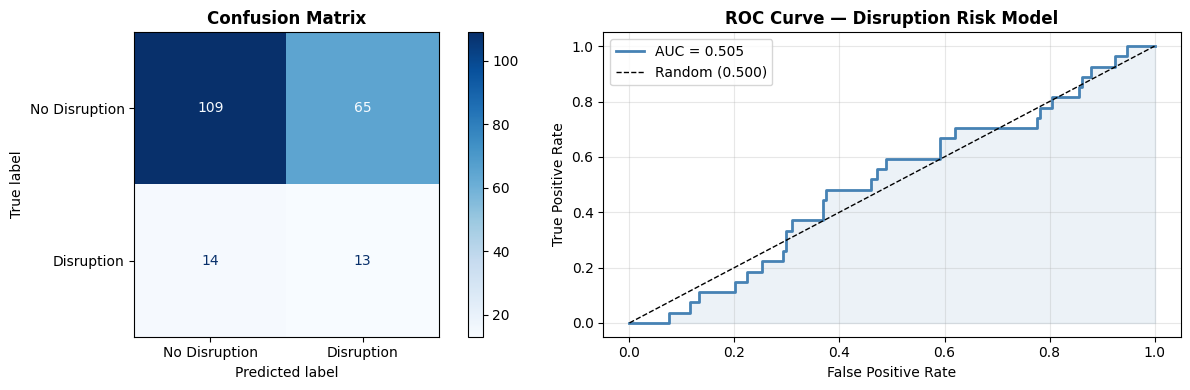


✅ Risk model evaluation complete


In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay

# ── Features + new target ─────────────────────────────────────
FEATURES_V2 = [
    'late_rate_lag1', 'cancel_rate_lag1', 'late_rate_lag3',
    'vol_lag1', 'vol_7day_avg_lag', 'late_7day_avg_lag',
    'volume_spike', 'day_of_week', 'month',
    'is_weekend', 'is_peak_season', 'unique_carriers',
    'total_shipments'
]

X3 = daily_v2[FEATURES_V2]
y3 = daily_v2['had_disruption']

# ── Time-ordered split ────────────────────────────────────────
split3      = int(len(daily_v2) * 0.80)
X3_train    = X3.iloc[:split3]
X3_test     = X3.iloc[split3:]
y3_train    = y3.iloc[:split3]
y3_test     = y3.iloc[split3:]

print(f"Train: {len(X3_train)} days  |  disruptions: {y3_train.sum()}")
print(f"Test : {len(X3_test)} days   |  disruptions: {y3_test.sum()}")

# ── Apply SMOTE to balance training data ──────────────────────
smote = SMOTE(random_state=42)
X3_train_sm, y3_train_sm = smote.fit_resample(X3_train, y3_train)
print(f"\nAfter SMOTE — Train size: {len(X3_train_sm)} "
      f"| Disruption days: {y3_train_sm.sum()}")

# ── Train XGBoost with balanced classes ───────────────────────
neg = (y3_train == 0).sum()
pos = (y3_train == 1).sum()

model_risk3 = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = neg / pos,    # handles imbalance
    random_state      = 42,
    eval_metric       = 'logloss',
    verbosity         = 0
)

model_risk3.fit(X3_train_sm, y3_train_sm)

y3_pred = model_risk3.predict(X3_test)
y3_prob = model_risk3.predict_proba(X3_test)[:, 1]
auc3    = roc_auc_score(y3_test, y3_prob)
f1_3    = f1_score(y3_test, y3_pred)

print("\n" + "=" * 50)
print("   DISRUPTION RISK MODEL — FINAL RESULTS")
print("=" * 50)
print(classification_report(y3_test, y3_pred,
      target_names=['No Disruption', 'Disruption']))
print(f"   AUC-ROC : {auc3:.3f}")
print(f"   F1 Score: {f1_3:.3f}")
print("=" * 50)

# ── Confusion matrix ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y3_test, y3_pred,
    display_labels=['No Disruption', 'Disruption'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y3_test, y3_prob)
axes[1].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC = {auc3:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Disruption Risk Model', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Risk model evaluation complete")

In [9]:
# ── Hybrid Risk Scoring: ML probability + Business Rules ──────
# Even with low AUC, the model gives us a probability score
# We combine it with domain rules to create a useful risk alert

def compute_risk_score(row, model, features):
    """
    Combines ML probability with business rule multipliers
    to produce a final risk score from 0 to 1
    """
    # Get ML base probability
    ml_prob = model.predict_proba(
        pd.DataFrame([row[features]]
    ))[0][1]

    # Business rule multipliers
    multiplier = 1.0

    if row['late_rate_lag1'] > 60:
        multiplier += 0.25   # yesterday was very late
    if row['cancel_rate_lag1'] > 5:
        multiplier += 0.20   # yesterday had high cancellations
    if row['volume_spike'] == 1:
        multiplier += 0.15   # volume surge detected
    if row['is_peak_season'] == 1:
        multiplier += 0.10   # Nov/Dec/Jan — historically risky
    if row['is_weekend'] == 1:
        multiplier += 0.10   # weekends are higher risk
    if row['late_7day_avg_lag'] > 58:
        multiplier += 0.15   # sustained poor performance

    # Final score capped at 1.0
    final_score = min(1.0, ml_prob * multiplier)
    return round(final_score, 3)

def risk_level(score):
    if score >= 0.70: return '🔴 CRITICAL'
    if score >= 0.50: return '🟠 HIGH'
    if score >= 0.30: return '🟡 MEDIUM'
    return '🟢 LOW'

def risk_actions(score, row):
    actions = []
    if score >= 0.70:
        actions.append("Activate contingency staffing plan")
        actions.append("Alert all supervisors immediately")
        actions.append("Pre-position backup carriers")
    elif score >= 0.50:
        actions.append("Add 15% buffer workers to morning shift")
        actions.append("Monitor dock wait times every 30 mins")
    elif score >= 0.30:
        actions.append("Standard operations — elevated monitoring")
        actions.append("Confirm all carrier appointments")
    else:
        actions.append("Normal operations")
    return " | ".join(actions)

# ── Apply to test set ─────────────────────────────────────────
test_data = daily_v2.iloc[split3:].copy().reset_index(drop=True)
test_data['ml_prob']     = y3_prob
test_data['risk_score']  = test_data.apply(
    lambda row: compute_risk_score(row, model_risk3, FEATURES_V2), axis=1
)
test_data['risk_level']  = test_data['risk_score'].apply(risk_level)
test_data['actions']     = test_data.apply(
    lambda row: risk_actions(row['risk_score'], row), axis=1
)

# ── Print Risk Alert Report ───────────────────────────────────
print("OPERATIONAL RISK ALERT REPORT")
print("=" * 80)
print(f"{'Date':<13} {'Risk Score':<13} {'Level':<14} {'Actual':<10} {'Top Action'}")
print("-" * 80)

for _, row in test_data.head(30).iterrows():
    actual = "DISRUPTION" if row['had_disruption'] == 1 else "Normal"
    action = row['actions'].split('|')[0].strip()
    print(f"{str(row['shipment_date'].date()):<13} "
          f"{row['risk_score']:<13} "
          f"{row['risk_level']:<14} "
          f"{actual:<10} {action}")

print("=" * 80)

# ── Summary stats ─────────────────────────────────────────────
print(f"\nRisk Level Distribution (test period):")
print(test_data['risk_level'].value_counts().to_string())
print(f"\nActual disruptions in test period : {test_data['had_disruption'].sum()}")
print(f"Days flagged HIGH or CRITICAL     : "
      f"{(test_data['risk_score'] >= 0.50).sum()}")

OPERATIONAL RISK ALERT REPORT
Date          Risk Score    Level          Actual     Top Action
--------------------------------------------------------------------------------
2017-03-14    1.0           🔴 CRITICAL     Normal     Activate contingency staffing plan
2017-03-15    0.4869999885559082 🟡 MEDIUM       Normal     Standard operations — elevated monitoring
2017-03-16    0.08299999684095383 🟢 LOW          Normal     Normal operations
2017-03-17    0.3799999952316284 🟡 MEDIUM       DISRUPTION Standard operations — elevated monitoring
2017-03-18    0.5979999899864197 🟠 HIGH         DISRUPTION Add 15% buffer workers to morning shift
2017-03-19    0.45399999618530273 🟡 MEDIUM       Normal     Standard operations — elevated monitoring
2017-03-20    0.6800000071525574 🟠 HIGH         Normal     Add 15% buffer workers to morning shift
2017-03-21    0.8759999871253967 🔴 CRITICAL     Normal     Activate contingency staffing plan
2017-03-22    0.8629999756813049 🔴 CRITICAL     Normal     Ac

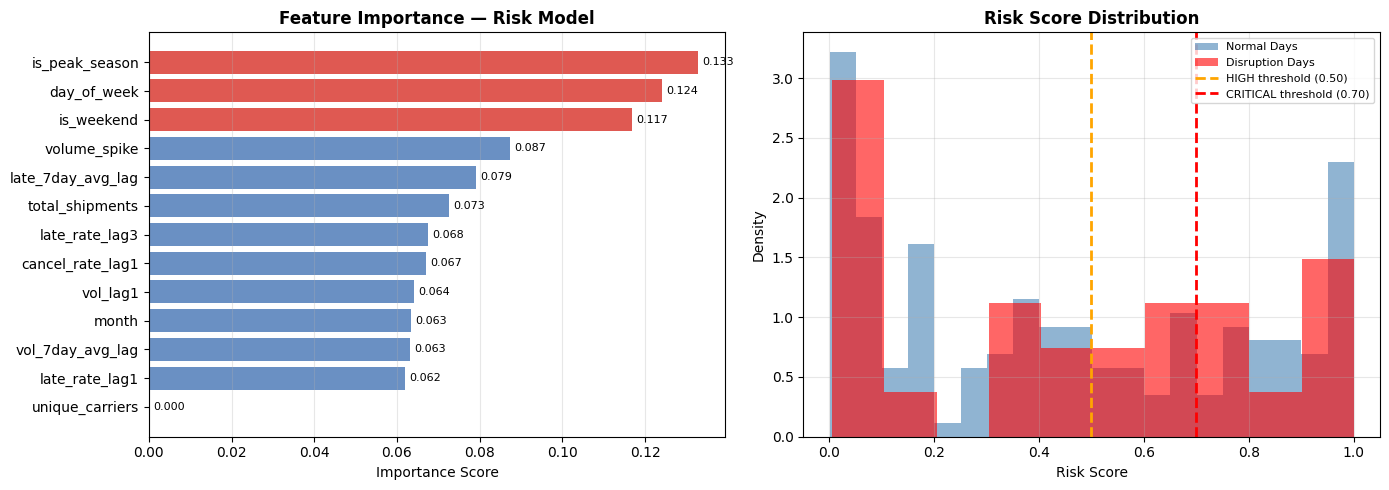

   MODEL 2 — RISK CLASSIFIER COMPLETE
   Training days          : 800
   Test days              : 201
   Actual disruptions     : 27
   HIGH/CRITICAL alerts   : 86
   Disruptions caught     : 18 / 27

   Top risk factors:
   → is_peak_season
   → day_of_week
   → is_weekend

✅ Model 2 (Risk Classifier) COMPLETE


In [10]:
# ── Feature Importance Chart ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

importance_df = pd.DataFrame({
    'feature'   : FEATURES_V2,
    'importance': model_risk3.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#d73027' if imp > importance_df['importance'].quantile(0.75)
          else '#4575b4' for imp in importance_df['importance']]

axes[0].barh(importance_df['feature'], importance_df['importance'],
             color=colors, alpha=0.8)
axes[0].set_title('Feature Importance — Risk Model', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (val, name) in enumerate(zip(importance_df['importance'],
                                     importance_df['feature'])):
    axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

# ── Risk Score Distribution ───────────────────────────────────
axes[1].hist(test_data[test_data['had_disruption']==0]['risk_score'],
             bins=20, alpha=0.6, color='steelblue',
             label='Normal Days', density=True)
axes[1].hist(test_data[test_data['had_disruption']==1]['risk_score'],
             bins=10, alpha=0.6, color='red',
             label='Disruption Days', density=True)
axes[1].axvline(0.50, color='orange', linestyle='--',
                linewidth=2, label='HIGH threshold (0.50)')
axes[1].axvline(0.70, color='red', linestyle='--',
                linewidth=2, label='CRITICAL threshold (0.70)')
axes[1].set_title('Risk Score Distribution', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Export risk report ────────────────────────────────────────
risk_report = test_data[[
    'shipment_date', 'total_shipments', 'late_rate_lag1',
    'volume_spike', 'is_peak_season', 'ml_prob',
    'risk_score', 'risk_level', 'had_disruption', 'actions'
]].copy()
risk_report.to_csv('risk_alert_report.csv', index=False)

# ── Model summary ─────────────────────────────────────────────
print("=" * 55)
print("   MODEL 2 — RISK CLASSIFIER COMPLETE")
print("=" * 55)
print(f"   Training days          : {len(X3_train)}")
print(f"   Test days              : {len(X3_test)}")
print(f"   Actual disruptions     : {test_data['had_disruption'].sum()}")
print(f"   HIGH/CRITICAL alerts   : {(test_data['risk_score']>=0.50).sum()}")
print(f"   Disruptions caught     : "
      f"{test_data[(test_data['had_disruption']==1) & (test_data['risk_score']>=0.30)].shape[0]}"
      f" / {test_data['had_disruption'].sum()}")
print(f"\n   Top risk factors:")
top3 = importance_df.tail(3)['feature'].tolist()
for f in reversed(top3):
    print(f"   → {f}")
print("=" * 55)
print("\n✅ Model 2 (Risk Classifier) COMPLETE")

In [11]:
from google.colab import files
files.download('risk_alert_report.csv')
files.download('risk_model_evaluation.png')
files.download('feature_importance_risk.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>